# Autômatos Celulares de Wolfram

**Objetivo:**
Aplicar o conteúdo ministrado sobre autômatos de Wolfram.

**Formato de entrega:**
- Relatório em PDF devidamente identificado
- Arquivo executável do código

---

## 1. Introdução
Este notebook implementa e explora os autômatos celulares elementares de Wolfram, permitindo ao usuário:
- Escolher o número da regra (0 a 255)
- Selecionar o estado inicial (sítio central ocupado ou aleatório)
- Definir a densidade inicial e o agrupamento dos sítios ocupados
- Visualizar a evolução espaço-temporal do autômato
- Explorar exemplos de regras homogêneas, periódicas, caóticas e complexas

---

## 2. Importação das Bibliotecas e Preparação de Pastas

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from matplotlib import colors
from IPython.display import display, clear_output
from ipywidgets import (
    IntSlider,
    FloatSlider,
    BoundedIntText,
    BoundedFloatText,
    RadioButtons,
    Checkbox,
    Button,
    VBox,
    HBox,
    Output,
    Layout,
    jslink,
    interact,
    interactive_output,
)

# Criação de pastas para resultados
os.makedirs("dados/input", exist_ok=True)
os.makedirs("dados/output", exist_ok=True)
os.makedirs("graficos", exist_ok=True)

## 3. Funções Utilitárias (Únicas e Sem Repetição)

In [12]:
def regra_para_binario(regra):
    """Converte número da regra (0-255) em vetor binário de 8 bits."""
    return np.array([int(bit) for bit in f"{regra:08b}"])

def estado_inicial(n, tipo='central', densidade=0.5, agrupado=False):
    """
    Gera o estado inicial do autômato.
    tipo: 'central' (um sítio central ocupado) ou 'aleatorio'
    densidade: fração de sítios ocupados (usado se tipo='aleatorio')
    agrupado: se True, sítios ocupados ficam agrupados
    """
    estado = np.zeros(n, dtype=int)
    if tipo == 'central':
        estado[n//2] = 1
    elif tipo == 'aleatorio':
        k = int(densidade * n)
        if agrupado:
            inicio = random.randint(0, n-k)
            estado[inicio:inicio+k] = 1
        else:
            ocupados = random.sample(range(n), k)
            estado[ocupados] = 1
    return estado

def aplicar_regra(estado, regra_binaria):
    tamanho = len(estado)
    novo_estado = np.zeros(tamanho, dtype=int)
    for i in range(tamanho):
        esquerda = estado[(i - 1) % tamanho]
        centro   = estado[i]
        direita  = estado[(i + 1) % tamanho]
        padrao = (esquerda << 2) | (centro << 1) | direita
        novo_estado[i] = regra_binaria[7 - padrao]
    return novo_estado

def simular(regra, tamanho=101, passos=100, tipo_ini='central', densidade=0.5, agrupado=False):
    regra_binaria = regra_para_binario(regra)
    estado = estado_inicial(tamanho, tipo_ini, densidade, agrupado)
    evolucao = [estado.copy()]
    for _ in range(passos):
        estado = aplicar_regra(estado, regra_binaria)
        evolucao.append(estado.copy())
    return np.array(evolucao)

def plotar(evolucao, regra, classe=None, tamanho=101, passos=100, salvar=False):
    plt.figure(figsize=(10, 6))
    plt.imshow(evolucao, cmap='binary')
    titulo = f"Regra {regra}" if not classe else f"{classe} - Regra {regra}"
    plt.title(titulo)
    plt.xlabel('Células')
    plt.ylabel('Tempo')
    if salvar:
        nome = f"graficos/{'regra_'+str(regra) if not classe else classe+'_regra_'+str(regra)}.png"
        plt.savefig(nome)
    plt.show()
    plt.close()

In [13]:
def salvar_input(regra, tamanho, passos, tipo_ini, densidade, agrupado):
    """Salva os parâmetros de entrada em CSV na pasta dados/input."""
    pasta = os.path.join("dados", "input")
    os.makedirs(pasta, exist_ok=True)
    nome = f"regra_{regra}_tamanho_{tamanho}_passos_{passos}_tipo_{tipo_ini}_dens_{densidade}_agrup_{agrupado}.csv"
    caminho = os.path.join(pasta, nome)
    parametros = np.array([
        ["regra", regra],
        ["tamanho", tamanho],
        ["passos", passos],
        ["tipo_ini", tipo_ini],
        ["densidade", densidade],
        ["agrupado", agrupado]
    ])
    np.savetxt(caminho, parametros, fmt='%s', delimiter=",")

def salvar_output(evolucao, regra, tamanho, passos, tipo_ini, densidade, agrupado):
    """Salva a evolução do autômato em CSV na pasta dados/output."""
    pasta = os.path.join("dados", "output")
    os.makedirs(pasta, exist_ok=True)
    nome = f"regra_{regra}_tamanho_{tamanho}_passos_{passos}_tipo_{tipo_ini}_dens_{densidade}_agrup_{agrupado}.csv"
    caminho = os.path.join(pasta, nome)
    np.savetxt(caminho, evolucao, fmt='%d', delimiter=",")


In [14]:
def classificar_regra(regra):
    """Classifica a regra segundo Wolfram."""
    # Classes principais (exemplos clássicos)
    classes = {
        'Homogêneo': [0, 8, 32, 160, 250, 255],
        'Periódico': [4, 12, 36, 44, 73, 77, 78, 94, 104, 108, 128, 132, 136, 140, 156, 204],
        'Caótico': [18, 22, 30, 45, 60, 90, 105, 106, 122, 126, 146, 150, 170, 182],
        'Complexo': [54, 110]
    }
    for classe, regras in classes.items():
        if regra in regras:
            return classe
    return 'Desconhecida'

## 4. Interface Interativa para Exploração

In [ ]:
def interface_interativa():
    # Margem superior de 3 px para alinhar os campos de digitação aos sliders.
    txt_layout = Layout(width='90px', margin='3px 0 0 8px')

    regra_slider = IntSlider(min=0, max=255, step=1, value=30, description='Regra', layout=Layout(width='420px'))
    regra_txt = BoundedIntText(min=0, max=255, step=1, value=30, layout=txt_layout)

    tamanho_slider = IntSlider(min=21, max=201, step=10, value=101, description='Tamanho', layout=Layout(width='420px'))
    tamanho_txt = BoundedIntText(min=21, max=201, step=10, value=101, layout=txt_layout)

    passos_slider = IntSlider(min=10, max=200, step=10, value=100, description='Passos', layout=Layout(width='420px'))
    passos_txt = BoundedIntText(min=10, max=200, step=10, value=100, layout=txt_layout)

    densidade_slider = FloatSlider(min=0.05, max=1.0, step=0.05, value=0.5, description='Densidade', layout=Layout(width='420px'))
    densidade_txt = BoundedFloatText(min=0.05, max=1.0, step=0.05, value=0.5, layout=txt_layout)

    tipo_ini = RadioButtons(options=['central', 'aleatorio'], value='central', description='Estado inicial')
    agrupado = Checkbox(value=False, description='Agrupado')
    botao = Button(description='Executar', button_style='primary')
    saida = Output()

    jslink((regra_slider, 'value'), (regra_txt, 'value'))
    jslink((tamanho_slider, 'value'), (tamanho_txt, 'value'))
    jslink((passos_slider, 'value'), (passos_txt, 'value'))
    jslink((densidade_slider, 'value'), (densidade_txt, 'value'))

    def executar(_=None):
        regra = int(regra_slider.value)
        tamanho = int(tamanho_slider.value)
        passos = int(passos_slider.value)
        densidade = float(densidade_slider.value)
        tipo = tipo_ini.value
        agr = bool(agrupado.value)

        classe = classificar_regra(regra)
        evolucao = simular(regra, tamanho, passos, tipo, densidade, agr)
        salvar_input(regra, tamanho, passos, tipo, densidade, agr)
        salvar_output(evolucao, regra, tamanho, passos, tipo, densidade, agr)

        with saida:
            clear_output(wait=True)
            plotar(evolucao, regra, classe, tamanho, passos)

    botao.on_click(executar)

    ui = VBox([
        HBox([regra_slider, regra_txt]),
        HBox([tamanho_slider, tamanho_txt]),
        HBox([passos_slider, passos_txt]),
        HBox([densidade_slider, densidade_txt]),
        tipo_ini,
        agrupado,
        botao,
        saida,
    ])

    display(ui)
    executar()

# Executar interface interativa
interface_interativa()

interactive(children=(IntSlider(value=30, description='Regra', max=255), IntSlider(value=101, description='Tam…

## 5. Exemplos de Regras Típicas

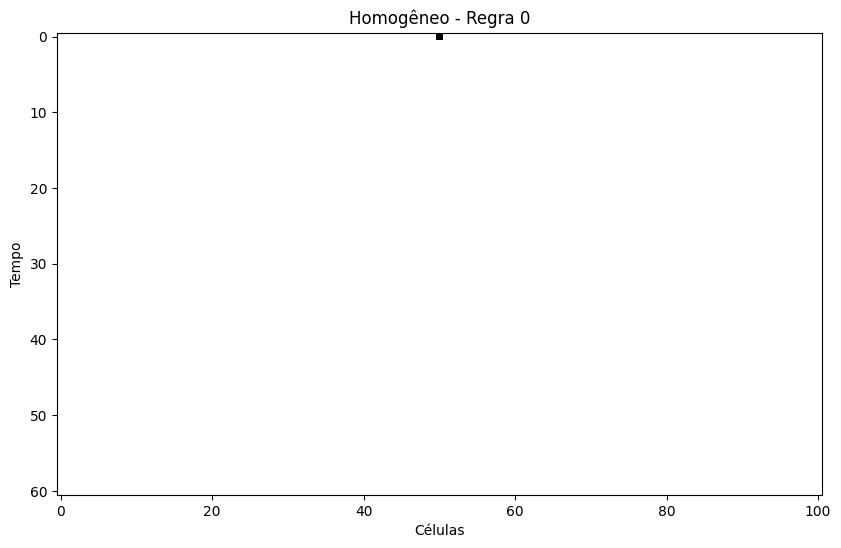

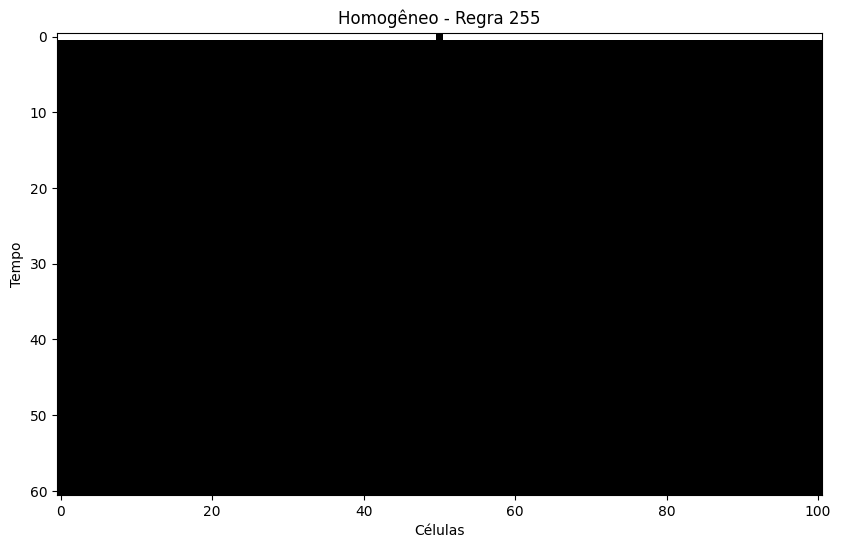

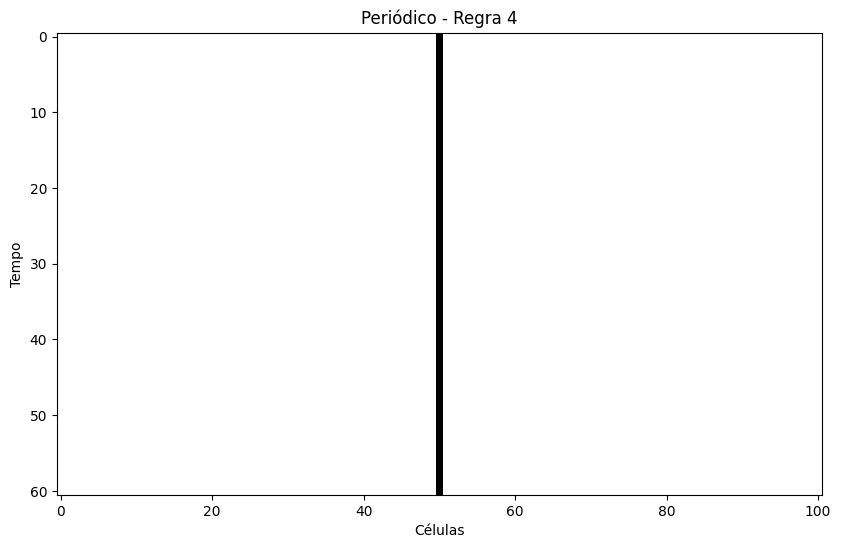

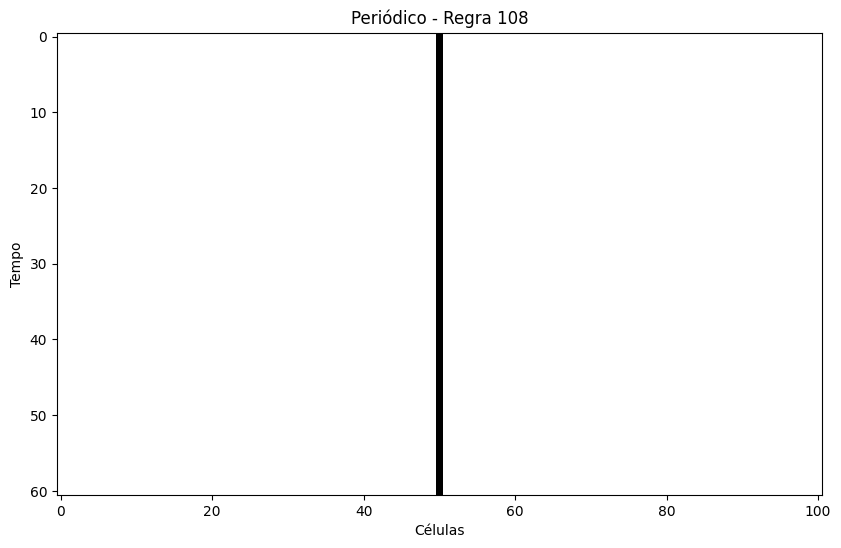

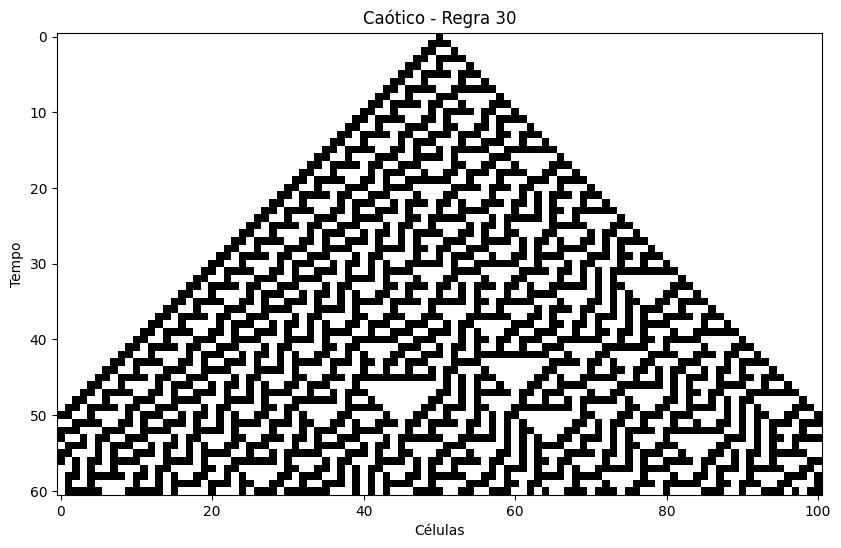

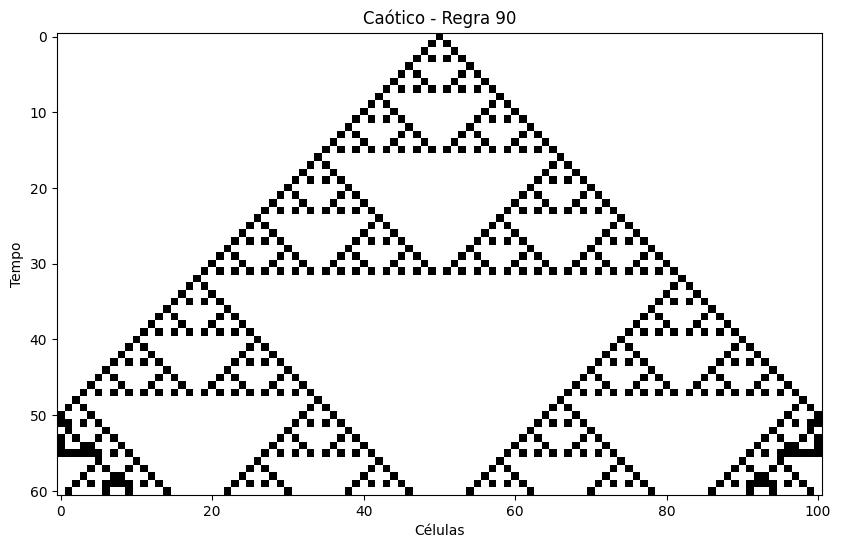

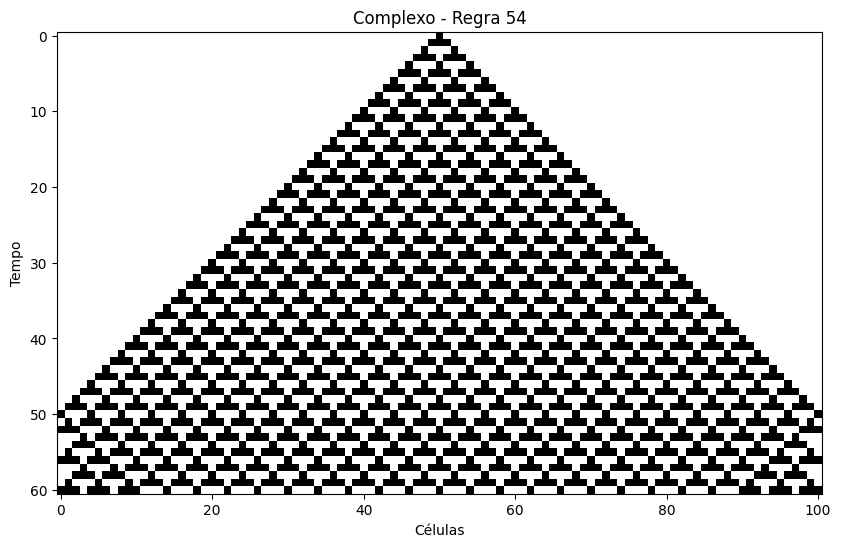

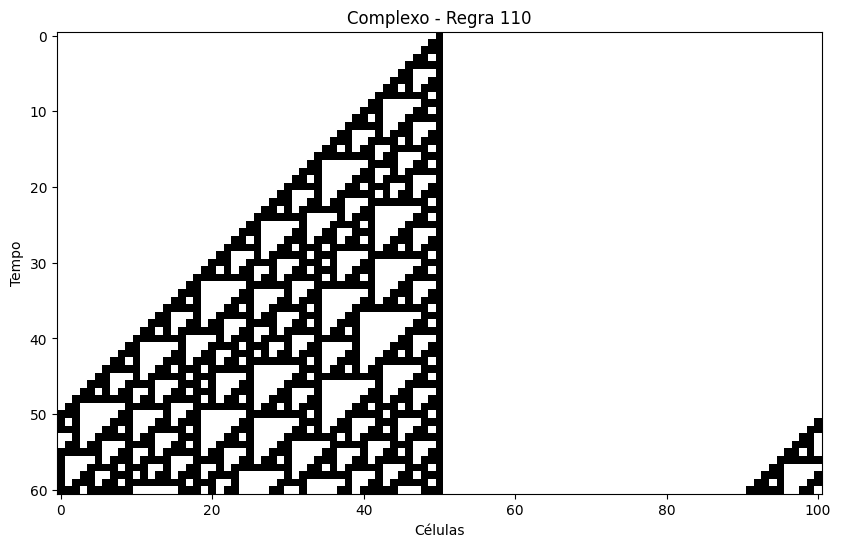

In [16]:
# Regras típicas para cada classe
regras_exemplo = {
    'Homogêneo': [0, 255],
    'Periódico': [4, 108],
    'Caótico': [30, 90],
    'Complexo': [54, 110]
}

for classe, regras in regras_exemplo.items():
    for regra in regras:
        tamanho = 101
        passos = 60
        tipo_ini = 'central'
        densidade = 0.5
        agrupado = False
        evolucao = simular(regra, tamanho=tamanho, passos=passos, tipo_ini=tipo_ini, densidade=densidade, agrupado=agrupado)
        salvar_input(regra, tamanho, passos, tipo_ini, densidade, agrupado)
        salvar_output(evolucao, regra, tamanho, passos, tipo_ini, densidade, agrupado)
        plotar(evolucao, regra, classe, tamanho=tamanho, passos=passos, salvar=True)


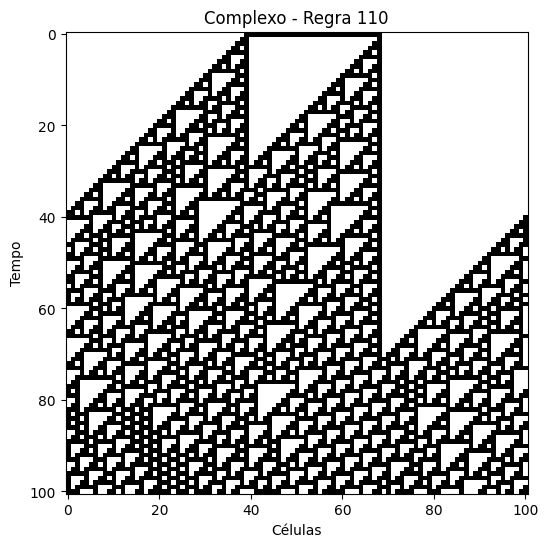

In [17]:
# Exemplo de execução não interativa
# Simula e plota a evolução da Regra 110 com condição inicial aleatória
regra = 110
classe = classificar_regra(regra)
tamanho = 101
passos = 100
tipo_ini = 'aleatorio'
densidade = 0.3
agrupado = True

# Simulação
evolucao = simular(regra, tamanho, passos, tipo_ini, densidade, agrupado)
# Salva os dados
salvar_input(regra, tamanho, passos, tipo_ini, densidade, agrupado)
salvar_output(evolucao, regra, tamanho, passos, tipo_ini, densidade, agrupado)
# Plota o resultado
plotar(evolucao, regra, classe, tamanho, passos)
